In [44]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import h5py
import re

In [45]:
# ========= 1. 設定 (Configuration) =========

base_dir = r"C:\experiment\1D"

# 每個 group 可以包含多個實驗檔（合併後統計）
experiments = [
    {"group_val":  5, "group": "5cm", "files": [
        {"csv": os.path.join(base_dir, "t0103", "t0103.csv"), "h5": os.path.join(base_dir, "t0103", "t0103.h5")},
    ]},
    {"group_val":  7, "group": "7cm", "files": [
        {"csv": os.path.join(base_dir, "t0104", "t0104.csv"), "h5": os.path.join(base_dir, "t0104", "t0104.h5")},
    ]},
    {"group_val": 10, "group": "10cm", "files": [
        {"csv": os.path.join(base_dir, "t0105", "t0105.csv"), "h5": os.path.join(base_dir, "t0105", "t0105.h5")},
    ]},
    {"group_val": 12, "group": "12cm", "files": [
        {"csv": os.path.join(base_dir, "t0106", "t0106.csv"), "h5": os.path.join(base_dir, "t0106", "t0106.h5")},
    ]},
    # t0100 與 t0107 均為 15cm，合併為同一群組
    {"group_val": 15, "group": "15cm", "files": [
        {"csv": os.path.join(base_dir, "t0100", "t0100.csv"), "h5": os.path.join(base_dir, "t0100", "t0100.h5")},
        {"csv": os.path.join(base_dir, "t0107", "t0107.csv"), "h5": os.path.join(base_dir, "t0107", "t0107.h5")},
    ]},
]

# 繪圖 X 軸 (Normal Stress) 範圍
xlim_min = 6
xlim_max = 34

In [46]:
# ========= 2. 資料處理 (Data Processing) =========

def extract_sigma(run_name):
    """ 從 run1_32MPa 這樣的字串中提取 32 作數值 """
    match = re.search(r'_(\d+)MPa', str(run_name))
    if match:
        return float(match.group(1))
    return np.nan

def get_run_index(run_str):
    match = re.search(r'run(\d+)', str(run_str))
    return int(match.group(1)) if match else None

def extract_max_sliprate_from_h5(h5_path, run_index):
    """
    讀取 HDF5 中特定 run_index 的 max slip rate。
    只取中間 sensor (ch13) 的 max slip rate。
    位移單位為 μm，故 slip rate 單位為 μm/s。
    """
    if not os.path.exists(h5_path): return np.nan
    
    try:
        with h5py.File(h5_path, 'r') as f:
            run_idx_str = str(int(run_index) - 1) # run1 -> 0
            if "runs" not in f or run_idx_str not in f["runs"]:
                return np.nan
            
            run_group = f["runs"][run_idx_str]
            th_group = run_group["time history"]
            
            # 只看中間 sensor (ch13)
            ch = 13
            bg_max = 0
            if f'sliprate_ch{ch}' in th_group:
                rate_data = th_group[f'sliprate_ch{ch}'][:]
                if len(rate_data) > 0:
                    bg_max = np.max(rate_data)
            
            hr_max = 0
            if "high_rate_sliprates" in th_group:
                hr_group = th_group["high_rate_sliprates"]
                hr_keys = [k for k in hr_group.keys() if f'high_sliprate_ch{ch}_blk' in k]
                hr_max_list = []
                for k in hr_keys:
                    data = hr_group[k][:]
                    if len(data) > 0:
                        hr_max_list.append(np.max(data))
                if hr_max_list:
                    hr_max = max(hr_max_list)
            
            return max(bg_max, hr_max)
    except Exception as e:
        print(f"讀取 {h5_path} run {run_index} 發生錯誤: {e}")
        return np.nan

def process_max_sliprate_data():
    """
    讀取 CSV 確定哪些 run 未被 skip，然後從 HDF5 讀取 max sliprate。
    同一 group 底下的多個檔案會合併後一起計算統計量。
    """
    processed_data = []
    for exp in experiments:
        group_df_list = []
        
        for finfo in exp['files']:
            if not os.path.exists(finfo['csv']) or not os.path.exists(finfo['h5']):
                print(f"找不到檔案: {finfo['csv']} 或 {finfo['h5']}，略過")
                continue

            df = pd.read_csv(finfo['csv'])

            # 藉由 CSV 檔案排除 skip 的 run
            if 'skipped' in df.columns:
                df = df[df['skipped'] != 'YES'].copy()

            # 萃取 sigma 與 run_index
            df['sigma'] = df['Run'].apply(extract_sigma)
            df['run_index'] = df['Run'].apply(get_run_index)

            # 從 HDF5 計算 max_sliprate
            df['max_sliprate'] = df['run_index'].apply(
                lambda idx: extract_max_sliprate_from_h5(finfo['h5'], idx)
            )
            group_df_list.append(df)

        if not group_df_list:
            continue

        # 合併同一 group 的所有資料
        combined_df = pd.concat(group_df_list, ignore_index=True)
        combined_df = combined_df.dropna(subset=['sigma', 'max_sliprate'])

        # 計算每個 sigma 的統計量
        stats = combined_df.groupby('sigma')['max_sliprate'].agg(
            median='median',
            q1=lambda x: x.quantile(0.25),
            q3=lambda x: x.quantile(0.75)
        ).reset_index()

        processed_data.append({
            'group': exp['group'],
            'group_val': exp['group_val'],
            'stats': stats
        })
    return processed_data

In [47]:
custom_colors = ['#F4A63A', '#A2C4F1', '#A5D1B0', '#DF562C', '#CEBAF0', '#E8D2B3', '#015493']

In [48]:
# ========= 3. 繪圖函式 (Plotting Function) =========

def plot_max_sliprate_by_sigma(title="Max Slip Rate vs Normal Stress", ylabel=r"Max Slip Rate [$\mu$m/s]"):
    """以 sigma 為 X 軸繪圖，不同 group 各一條序列。"""
    data_to_plot = process_max_sliprate_data()

    if not data_to_plot:
        print(f"沒有可供繪圖的資料")
        return

    # colormap：以 group_val 排序對應 custom_colors
    group_vals = [item['group_val'] for item in data_to_plot]
    n = len(group_vals)
    colors = custom_colors[:n]
    val_to_idx = {v: i for i, v in enumerate(group_vals)}

    # 建立 colorbar 用的 ScalarMappable
    from matplotlib.colors import ListedColormap, BoundaryNorm
    cmap_cb = ListedColormap(colors)
    bounds = [i - 0.5 for i in range(n)] + [n - 0.5]
    norm_cb = BoundaryNorm(bounds, cmap_cb.N)
    sm = plt.cm.ScalarMappable(cmap=cmap_cb, norm=norm_cb)
    sm.set_array([])

    fig, ax = plt.subplots(figsize=(8, 5))

    all_sigmas = []
    texts_to_draw = []
    for item in data_to_plot:
        stats = item['stats']
        sigmas = stats['sigma'].values
        medians = stats['median'].values
        yerr_lower = medians - stats['q1'].values
        yerr_upper = stats['q3'].values - medians
        color = colors[val_to_idx[item['group_val']]]

        all_sigmas.extend(sigmas)

        ax.errorbar(
            sigmas, medians,
            yerr=[yerr_lower, yerr_upper],
            fmt='s', color=color,
            markersize=8, capsize=5,
            markeredgewidth=1, markeredgecolor='gray',
            elinewidth=1.2, alpha=0.8, zorder=3
        )

        # 趨勢線
        if len(sigmas) > 1:
            slope, intercept = np.polyfit(sigmas, medians, 1)
            x_line = np.array([sigmas.min(), sigmas.max()])
            y_line = slope * x_line + intercept
            ax.plot(x_line, y_line, color=color, linestyle='--', linewidth=1.5, alpha=0.6, zorder=2)
            texts_to_draw.append({
                'x': x_line[-1] + 0.5,
                'y': y_line[-1],
                'text': f' m={slope:.3g}',
                'color': color
            })

    ax.set_xlabel(r'Normal Stress $\sigma$ [MPa]', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.grid(axis='y', alpha=0.6)
    ax.set_xlim(xlim_min, xlim_max)

    if all_sigmas:
        ax.set_xticks(np.unique(all_sigmas))

    # Y 軸科學記號
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0), useMathText=True)

    # colorbar 取代圖例
    cbar = fig.colorbar(sm, ax=ax, ticks=list(range(n)), aspect=30)
    cbar.set_label('Seismogenic Zone Length', fontsize=12)
    cbar.ax.set_yticklabels([item['group'] for item in data_to_plot])
    plt.tight_layout()
    plt.show()

def plot_max_sliprate_by_group(title="Max Slip Rate vs Fault Length", ylabel=r"Max Slip Rate [$\mu$m/s]"):
    """以群組為 X 軸（數值型），不同 sigma 各一條序列。"""
    group_order = [exp['group'] for exp in experiments]
    group_xval  = {exp['group']: exp['group_val'] for exp in experiments}

    data_to_plot = process_max_sliprate_data()

    if not data_to_plot:
        print(f"沒有可供繪圖的資料")
        return

    # 收集所有出現的 sigma
    all_sigmas_set = set()
    for item in data_to_plot:
        all_sigmas_set.update(item['stats']['sigma'].values)
    unique_sigmas = sorted(all_sigmas_set)

    # colormap：以 sigma 排序對應 custom_colors
    n = len(unique_sigmas)
    colors = custom_colors[:n]
    sigma_to_idx = {s: i for i, s in enumerate(unique_sigmas)}

    # 建立 colorbar 用的 ScalarMappable
    from matplotlib.colors import ListedColormap, BoundaryNorm
    cmap_cb = ListedColormap(colors)
    bounds = [i - 0.5 for i in range(n)] + [n - 0.5]
    norm_cb = BoundaryNorm(bounds, cmap_cb.N)
    sm = plt.cm.ScalarMappable(cmap=cmap_cb, norm=norm_cb)
    sm.set_array([])

    fig, ax = plt.subplots(figsize=(8, 5))
    texts_to_draw = []

    for sigma in unique_sigmas:
        x_vals, y_vals, yerr_lo, yerr_hi = [], [], [], []

        for item in data_to_plot:
            group = item['group']
            if group not in group_xval:
                continue
            stats = item['stats']
            row = stats[stats['sigma'] == sigma]
            if row.empty:
                continue
            x_vals.append(group_xval[group])
            med = row['median'].values[0]
            q1  = row['q1'].values[0]
            q3  = row['q3'].values[0]
            y_vals.append(med)
            yerr_lo.append(med - q1)
            yerr_hi.append(q3 - med)

        if not x_vals:
            continue

        x_arr = np.array(x_vals)
        y_arr = np.array(y_vals)
        color = colors[sigma_to_idx[sigma]]

        ax.errorbar(
            x_arr, y_arr,
            yerr=[np.array(yerr_lo), np.array(yerr_hi)],
            fmt='s', color=color,
            markersize=10, capsize=5,
            markeredgewidth=1, markeredgecolor='gray',
            elinewidth=1.2, alpha=1, zorder=3
        )

        # 趨勢線
        if len(x_arr) > 1:
            slope, intercept = np.polyfit(x_arr, y_arr, 1)
            x_line = np.array([x_arr.min(), x_arr.max()])
            y_line = slope * x_line + intercept
            ax.plot(x_line, y_line, color=color, linestyle='--', linewidth=1.5, alpha=0.6, zorder=2)
            texts_to_draw.append({
                'x': x_line[-1] + 0.1,
                'y': y_line[-1],
                'text': f' m={slope:.3g}',
                'color': color
            })

    ax.set_xlabel('Seismogenic Zone Length', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=14)
    x_vals_all = list(group_xval.values())
    ax.set_xlim(min(x_vals_all) - 1, max(x_vals_all) + 1)
    ax.set_xticks(x_vals_all)
    ax.set_xticklabels(group_order)
    ax.grid(axis='y', alpha=0.6)

    # Y 軸科學記號
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0), useMathText=True)

    # colorbar 取代圖例
    cbar = fig.colorbar(sm, ax=ax, ticks=list(range(n)), aspect=30)
    cbar.set_label(r'Normal Stress $\sigma$', fontsize=12)
    cbar.ax.set_yticklabels([f'{s:.0f} MPa' for s in unique_sigmas])
    plt.tight_layout()
    plt.show()

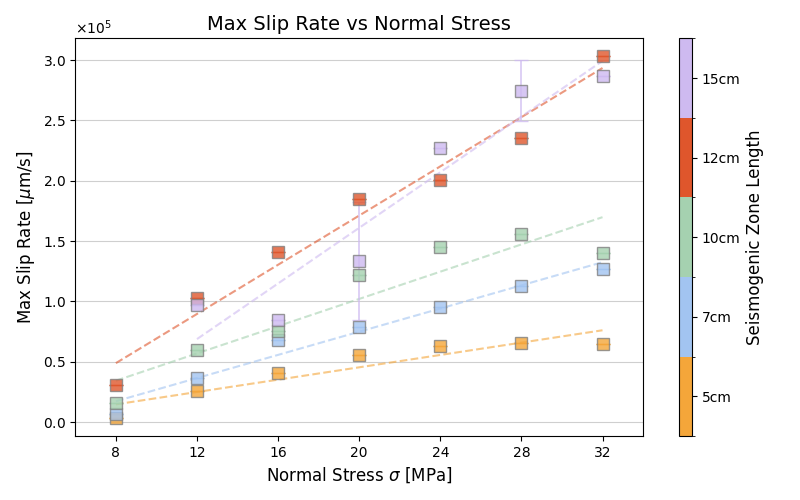

In [49]:
plot_max_sliprate_by_sigma()

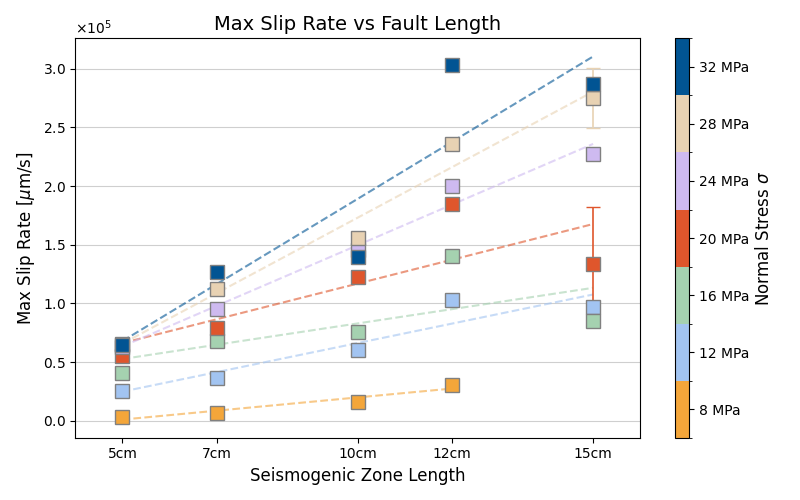

In [50]:
plot_max_sliprate_by_group()